In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [5]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="23f3003691_team",
    # Set the wandb project where this run will be logged.
    project="23f3003691-t22026",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sasivaibhav (23f3003691_team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


acc,▁▆▆▇▇██▇
loss,█▄▂▂▂▂▂▁
acc,0.74286
loss,0.20232


In [6]:
#sample dummy submission
import os
import pandas as pd
import numpy as np

DATA_DIR = "/kaggle/input/competitions/smart-mcq-solver-challenge"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

def generate_baseline_submission():
    print("--- Loading Datasets ---")
    train_df = pd.read_csv(TRAIN_PATH)
    test_df = pd.read_csv(TEST_PATH)
    sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
    
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    
    # 1. Explicitly define the column names to handle case mismatches
    test_id_col = 'id'                     # Lowercase in test.csv
    sub_id_col = sample_sub.columns[0]     # Uppercase 'ID' in sample_submission.csv
    pred_col = sample_sub.columns[1]       # 'Prediction'
    
    # 2. Create a basic dummy prediction
    dummy_prediction = "A B C"
    
    print(f"Generating dummy predictions ('{dummy_prediction}') for all rows...")
    
    # 3. Construct submission dataframe mapping test 'id' to submission 'ID'
    submission_df = pd.DataFrame({
        sub_id_col: test_df[test_id_col], 
        pred_col: [dummy_prediction] * len(test_df)
    })
    
    # 4. Save to the current working directory
    OUTPUT_PATH = "submission.csv"
    submission_df.to_csv(OUTPUT_PATH, index=False)
    
    print(f"\n--- Submission file successfully created at: {OUTPUT_PATH} ---")
    print(submission_df.head())

if __name__ == "__main__":
    generate_baseline_submission()

--- Loading Datasets ---
Train shape: (2000, 8)
Test shape: (500, 7)
Generating dummy predictions ('A B C') for all rows...

--- Submission file successfully created at: submission.csv ---
   ID Prediction
0   1      A B C
1   2      A B C
2   3      A B C
3   4      A B C
4   5      A B C


In [14]:
import pandas as pd
train_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")
print(train_df.head())

   id  \
0   1   
1   2   
2   3   
3   4   
4   5   

                                                                                                                    prompt  \
0  Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence?...   
1                                                                              What is accelerator-based light-ion fusion?   
2  Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting ...   
3  Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existenc...   
4           Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.   

                                                                                                                         A  \
0  Martin Heidegger believes that humans exist within a time c

In [7]:
"""
Smart MCQ Solver Challenge
Step 1: Preprocessing & EDA
Milestone 1 - NLP Foundation & Semantic Similarity

Run this as a Kaggle notebook by pasting each '# ---- CELL ----' block
into a separate cell, or run directly as a script.
"""

# ---- CELL: Imports ----
import os
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")

# ---- CELL: Paths & output folders ----
# On Kaggle: input files are read-only, so point TRAIN/TEST/SUB at /kaggle/input/...
# and write all outputs to /kaggle/working/ (the only writable directory).
IS_KAGGLE = os.path.exists("/kaggle/input")

if IS_KAGGLE:
    # TODO: replace <competition-folder-name> with the actual dataset folder
    # shown in the Kaggle "Input" panel on the right of the notebook.
    TRAIN_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
    TEST_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
    SUB_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv"
    OUT_DIR = "/kaggle/working"
else:
    TRAIN_PATH = "data/train.csv"
    TEST_PATH = "data/test.csv"
    SUB_PATH = "data/sample_submission.csv"
    OUT_DIR = "."

EDA_DIR = os.path.join(OUT_DIR, "eda_outputs")
DATA_OUT_DIR = os.path.join(OUT_DIR, "data")
os.makedirs(EDA_DIR, exist_ok=True)
os.makedirs(DATA_OUT_DIR, exist_ok=True)

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample submission shape:", sample_sub.shape)

OPTION_COLS = ["A", "B", "C", "D", "E"]

# ---- CELL: Basic sanity checks ----
print("\n--- Nulls in train ---")
print(train.isnull().sum())
print("\n--- Nulls in test ---")
print(test.isnull().sum())

print("\n--- dtypes ---")
print(train.dtypes)

print("\n--- Answer label distribution ---")
print(train["answer"].value_counts())
print(train["answer"].value_counts(normalize=True).round(3))

# All answers should be one of A-E
assert train["answer"].isin(OPTION_COLS).all(), "Found an answer label outside A-E!"

# ---- CELL: Duplicate prompt analysis ----
dup_mask = train["prompt"].duplicated(keep=False)
print(f"\nRows involved in duplicate prompts: {dup_mask.sum()} out of {len(train)}")

# Peek at one duplicated-prompt group to understand what's going on
dup_prompts = train.loc[dup_mask, "prompt"].value_counts()
print("\nTop duplicated prompts (exact text match count):")
print(dup_prompts.head(10))

example_prompt = dup_prompts.index[0]
print(f"\nExample group for prompt: {example_prompt[:80]}...")
print(train[train["prompt"] == example_prompt][["id", "prompt", "answer"]])

# Check: are options/answers consistent within duplicate-prompt groups?
def group_consistency(g):
    return g[OPTION_COLS + ["answer"]].nunique().eq(1).all()

consistency = train[dup_mask].groupby("prompt").apply(group_consistency, include_groups=False)
print(f"\nDuplicate-prompt groups with fully consistent options+answer: "
      f"{consistency.sum()} / {len(consistency)}")

# ---- CELL: Near-duplicate check via normalized prompt (strip instruction wrapper) ----
# Many prompts look like "Pick the best possible answer: <core question> among the listed options."
# The wrapper phrasing varies but the core question repeats. Let's isolate the core question.
WRAPPER_PATTERNS = [
    r"^(pick the best possible answer:|select the most accurate option:|determine the correct option:|choose the correct answer:)\s*",
    r"\s*(among the listed options\.?|from the following choices\.?|carefully\.?)$",
]

def strip_wrapper(text: str) -> str:
    t = text.strip().lower()
    for pat in WRAPPER_PATTERNS:
        t = re.sub(pat, "", t, flags=re.IGNORECASE).strip()
    return t

train["core_prompt"] = train["prompt"].apply(strip_wrapper)
test["core_prompt"] = test["prompt"].apply(strip_wrapper)

core_dupes_train = train["core_prompt"].duplicated().sum()
print(f"\nDuplicate CORE prompts in train (after stripping instruction wrapper): {core_dupes_train}")

# Check overlap between train and test core prompts (possible leakage / near-identical Qs)
overlap = set(train["core_prompt"]) & set(test["core_prompt"])
print(f"Core prompts appearing in BOTH train and test: {len(overlap)}")

# ---- CELL: Text length features ----
def word_count(s: str) -> int:
    return len(str(s).split())

for col in ["prompt"] + OPTION_COLS:
    train[f"{col}_wc"] = train[col].apply(word_count)
    test_col = col if col in test.columns else None
    if test_col:
        test[f"{col}_wc"] = test[col].apply(word_count)

print("\nPrompt word count stats (train):")
print(train["prompt_wc"].describe())

print("\nOption word count stats (train, column A as example):")
print(train["A_wc"].describe())

# ---- CELL: Plot 1 - Answer distribution ----
plt.figure(figsize=(6, 4))
order = OPTION_COLS
sns.countplot(x="answer", hue="answer", data=train, order=order, palette="viridis", legend=False)
plt.title("Distribution of Correct Answer Labels (Train)")
plt.xlabel("Answer Option")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "answer_distribution.png"), dpi=150)
plt.close()

# ---- CELL: Plot 2 - Prompt length distribution ----
plt.figure(figsize=(7, 4))
sns.histplot(train["prompt_wc"], bins=30, kde=True, color="steelblue")
plt.title("Prompt Word Count Distribution (Train)")
plt.xlabel("Word count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "prompt_length_dist.png"), dpi=150)
plt.close()

# ---- CELL: Plot 3 - Option length distribution (all options combined) ----
option_lengths = pd.concat([train[f"{c}_wc"].rename("wc") for c in OPTION_COLS])
plt.figure(figsize=(7, 4))
sns.histplot(option_lengths, bins=30, kde=True, color="darkorange")
plt.title("Answer Option Word Count Distribution (Train, A-E combined)")
plt.xlabel("Word count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "option_length_dist.png"), dpi=150)
plt.close()

# ---- CELL: Plot 4 - Does answer length correlate with being correct? ----
melt_rows = []
for c in OPTION_COLS:
    sub = train[[c + "_wc", "answer"]].copy()
    sub["is_correct"] = (train["answer"] == c).astype(int)
    sub = sub.rename(columns={c + "_wc": "wc"})
    melt_rows.append(sub[["wc", "is_correct"]])
length_vs_correct = pd.concat(melt_rows, ignore_index=True)

plt.figure(figsize=(6, 4))
sns.boxplot(x="is_correct", y="wc", hue="is_correct", data=length_vs_correct, palette="Set2", legend=False)
plt.xticks([0, 1], ["Incorrect option", "Correct option"])
plt.title("Option Word Count: Correct vs Incorrect")
plt.ylabel("Word count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "length_vs_correctness.png"), dpi=150)
plt.close()

avg_correct_wc = length_vs_correct[length_vs_correct.is_correct == 1]["wc"].mean()
avg_incorrect_wc = length_vs_correct[length_vs_correct.is_correct == 0]["wc"].mean()
print(f"\nAvg word count - correct options: {avg_correct_wc:.2f}")
print(f"Avg word count - incorrect options: {avg_incorrect_wc:.2f}")
print("(If these are very different, a 'longest option' heuristic could be a naive baseline signal.)")

# ---- CELL: Text cleaning function (for TF-IDF stage next) ----
def clean_text(text: str) -> str:
    """Lowercase, strip punctuation/extra whitespace. Keep it light -
    TF-IDF benefits from minimal, non-destructive cleaning."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # urls
    text = re.sub(r"[^a-z0-9\s]", " ", text)               # punctuation -> space
    text = re.sub(r"\s+", " ", text).strip()               # collapse whitespace
    return text

for col in ["prompt"] + OPTION_COLS:
    train[f"{col}_clean"] = train[col].apply(clean_text)
    test[f"{col}_clean"] = test[col].apply(clean_text)

print("\nSample cleaned prompt:")
print("RAW  :", train.loc[0, "prompt"])
print("CLEAN:", train.loc[0, "prompt_clean"])

# ---- CELL: Save processed files for next step (TF-IDF modeling) ----
train.to_csv(os.path.join(DATA_OUT_DIR, "train_processed.csv"), index=False)
test.to_csv(os.path.join(DATA_OUT_DIR, "test_processed.csv"), index=False)
print(f"\nSaved train_processed.csv and test_processed.csv to {DATA_OUT_DIR}")
print(f"EDA plots saved to {EDA_DIR}")

Train shape: (2000, 8)
Test shape : (500, 7)
Sample submission shape: (500, 2)

--- Nulls in train ---
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

--- Nulls in test ---
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

--- dtypes ---
id         int64
prompt    object
A         object
B         object
C         object
D         object
E         object
answer    object
dtype: object

--- Answer label distribution ---
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64
answer
B    0.245
C    0.230
A    0.184
D    0.179
E    0.162
Name: proportion, dtype: float64

Rows involved in duplicate prompts: 454 out of 2000

Top duplicated prompts (exact text match count):
prompt
Select the most accurate option: How do the Lunar Laser Ranging Experiment, radar astronomy, and the Deep Space Network determine distances to the Moon, planets, and spacecraft? carefu

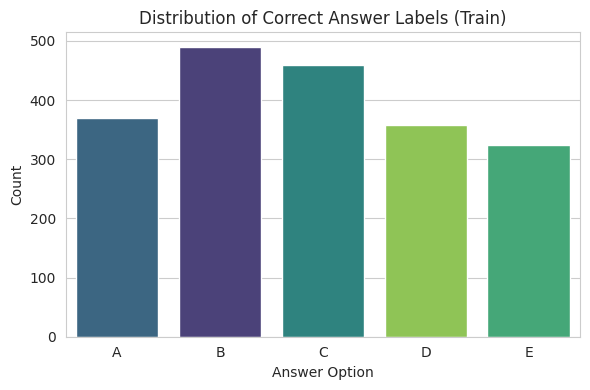

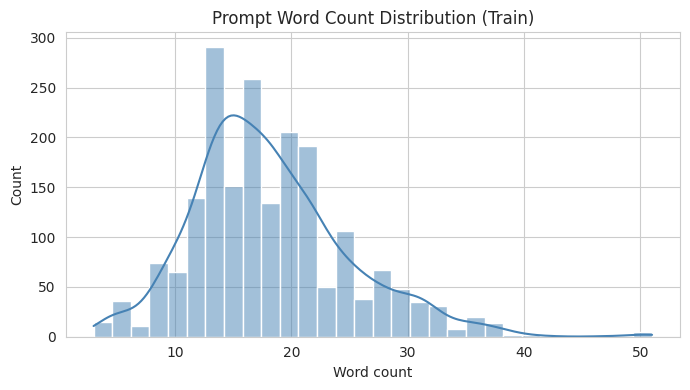

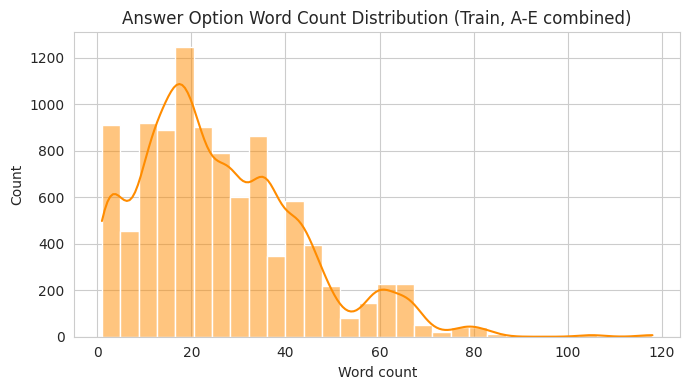

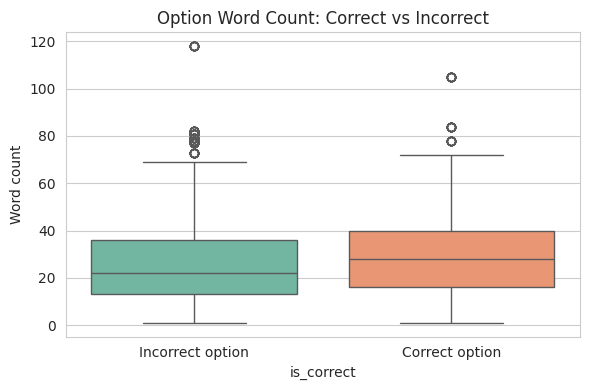

In [8]:
# ---- CELL: Plot 1 - Answer distribution ----
plt.figure(figsize=(6, 4))
order = OPTION_COLS
sns.countplot(x="answer", hue="answer", data=train, order=order, palette="viridis", legend=False)
plt.title("Distribution of Correct Answer Labels (Train)")
plt.xlabel("Answer Option")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "answer_distribution.png"), dpi=150)
plt.show()          # <-- ADD THIS
plt.close()

# ---- CELL: Plot 2 - Prompt length distribution ----
plt.figure(figsize=(7, 4))
sns.histplot(train["prompt_wc"], bins=30, kde=True, color="steelblue")
plt.title("Prompt Word Count Distribution (Train)")
plt.xlabel("Word count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "prompt_length_dist.png"), dpi=150)
plt.show()          # <-- ADD THIS
plt.close()

# ---- CELL: Plot 3 - Option length distribution ----
option_lengths = pd.concat([train[f"{c}_wc"].rename("wc") for c in OPTION_COLS])
plt.figure(figsize=(7, 4))
sns.histplot(option_lengths, bins=30, kde=True, color="darkorange")
plt.title("Answer Option Word Count Distribution (Train, A-E combined)")
plt.xlabel("Word count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "option_length_dist.png"), dpi=150)
plt.show()          # <-- ADD THIS
plt.close()

# ---- CELL: Plot 4 - Option length vs correctness ----
plt.figure(figsize=(6, 4))
sns.boxplot(x="is_correct", y="wc", hue="is_correct", data=length_vs_correct, palette="Set2", legend=False)
plt.xticks([0, 1], ["Incorrect option", "Correct option"])
plt.title("Option Word Count: Correct vs Incorrect")
plt.ylabel("Word count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "length_vs_correctness.png"), dpi=150)
plt.show()          # <-- ADD THIS
plt.close()

/tmp/ipykernel_58/4103894021.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=df_freq, palette='mako')


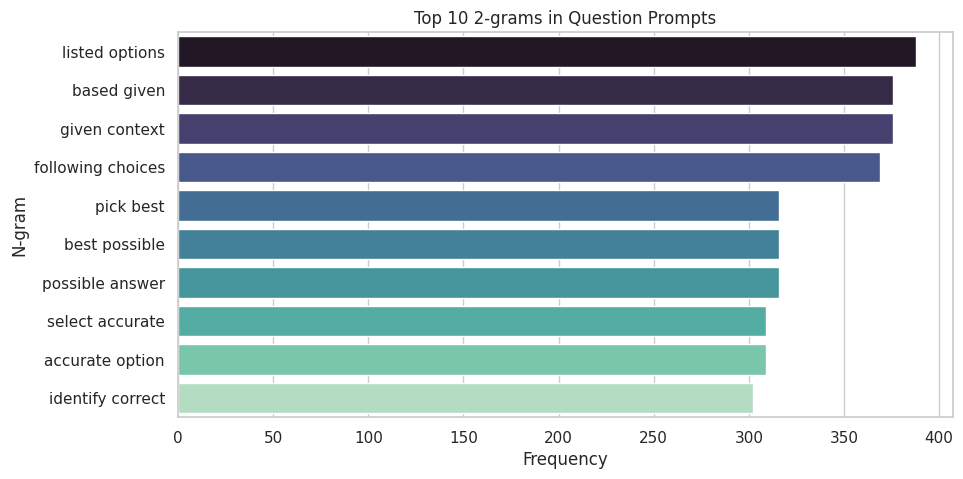

/tmp/ipykernel_58/4103894021.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='N-gram', data=df_freq, palette='mako')


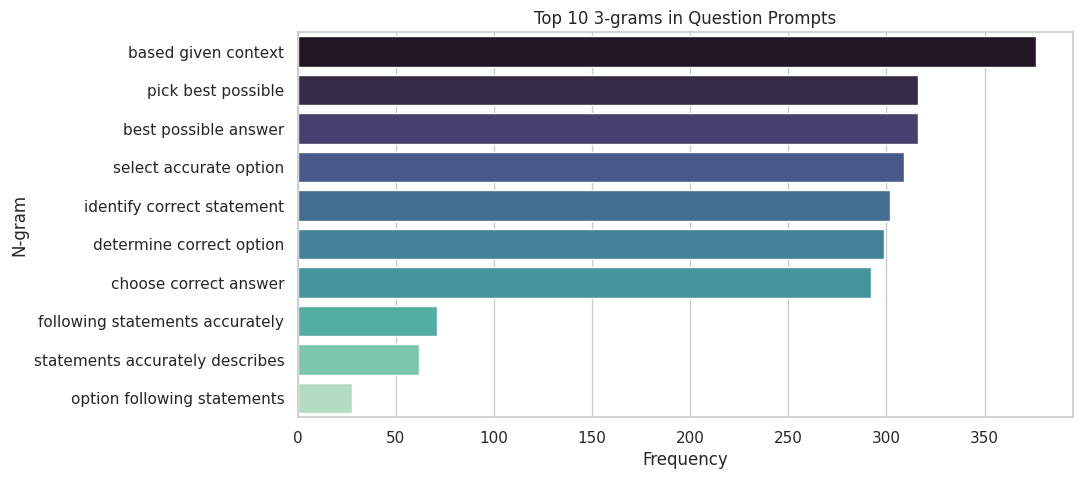

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, n=2, top_k=10):
    """Plots the most frequent n-grams in the text corpus."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:top_k]
    
    df_freq = pd.DataFrame(words_freq, columns=['N-gram', 'Frequency'])
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Frequency', y='N-gram', data=df_freq, palette='mako')
    plt.title(f'Top {top_k} {n}-grams in Question Prompts')
    plt.show()

# Run for bigrams (2 words) and trigrams (3 words)
plot_top_ngrams(train_df['prompt'], n=2)
plot_top_ngrams(train_df['prompt'], n=3)

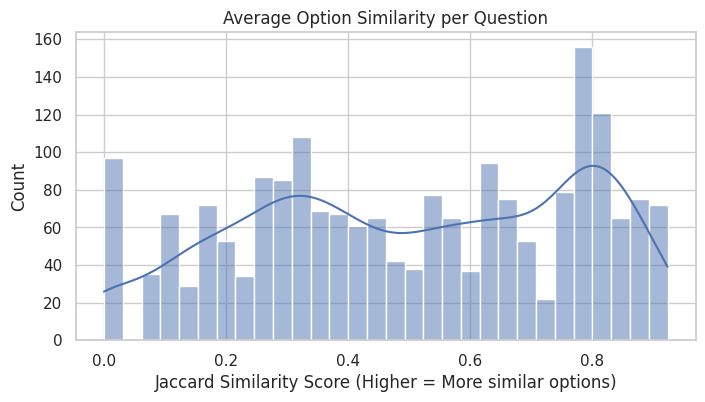

In [6]:
def jaccard_similarity(str1, str2):
    a = set(str1.lower().split())
    b = set(str2.lower().split())
    if not a or not b: return 0.0
    return len(a.intersection(b)) / len(a.union(b))

def calc_avg_option_similarity(row):
    options = [str(row['A']), str(row['B']), str(row['C']), str(row['D']), str(row['E'])]
    similarities = []
    # Compare every option against every other option
    for i in range(len(options)):
        for j in range(i + 1, len(options)):
            similarities.append(jaccard_similarity(options[i], options[j]))
    return np.mean(similarities)

train_df['option_similarity'] = train_df.apply(calc_avg_option_similarity, axis=1)

plt.figure(figsize=(8, 4))
sns.histplot(train_df['option_similarity'], bins=30, kde=True)
plt.title('Average Option Similarity per Question')
plt.xlabel('Jaccard Similarity Score (Higher = More similar options)')
plt.show()

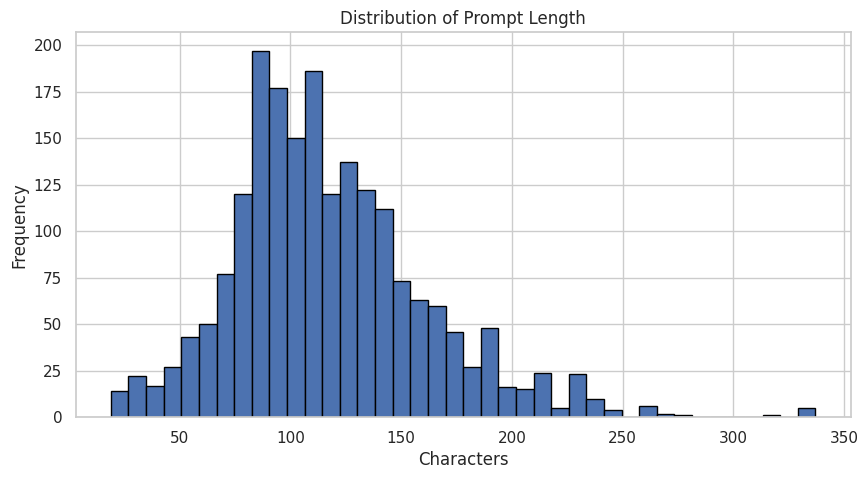

In [10]:
train_df['prompt_length'] = train_df['prompt'].str.len()

plt.figure(figsize=(10,5))

plt.hist(train_df['prompt_length'],
         bins=40,
         edgecolor='black')

plt.title("Distribution of Prompt Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

Train: (2000, 21) | Test: (500, 20)


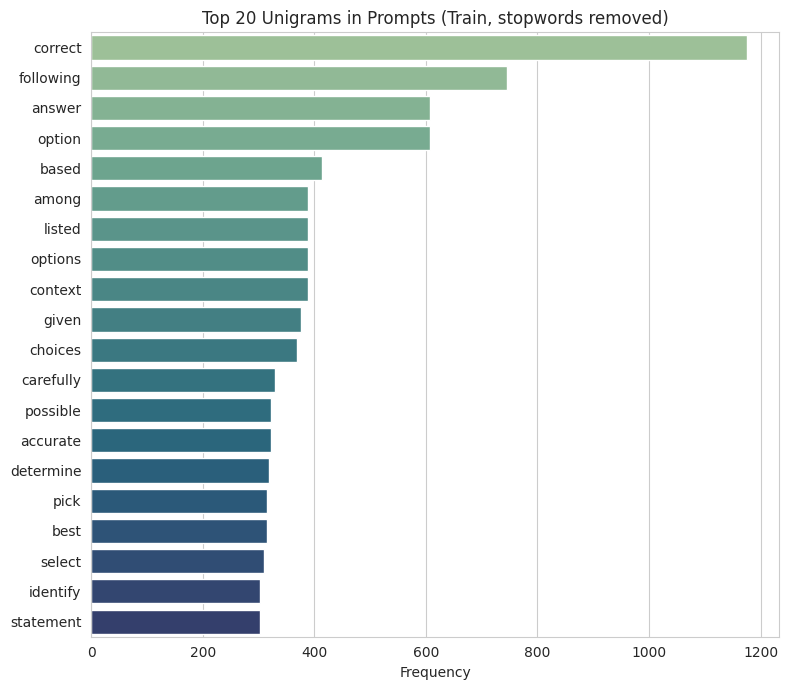

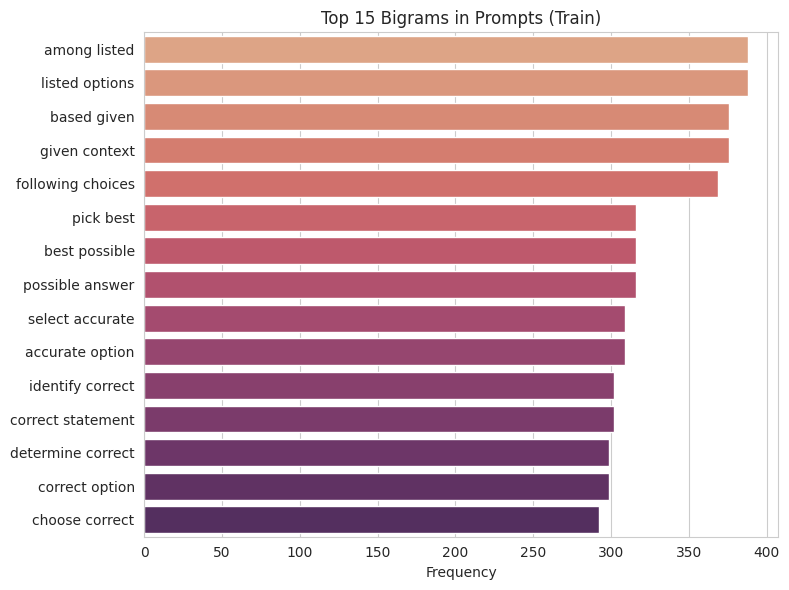

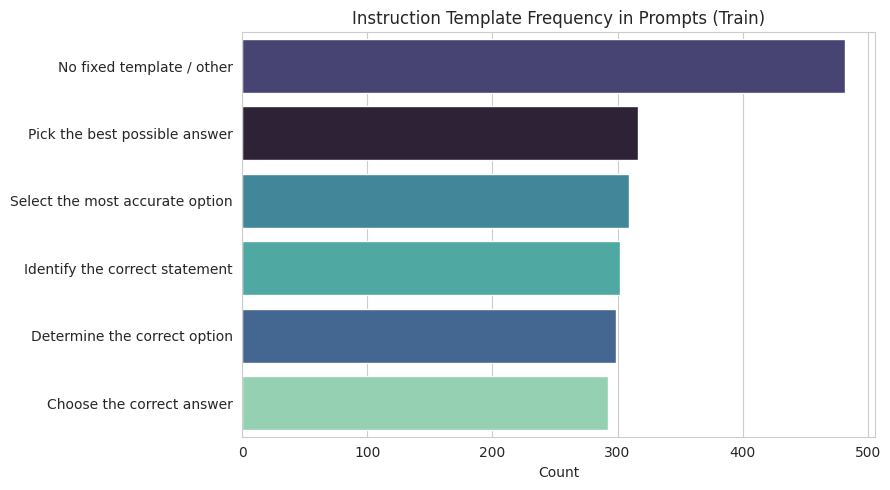

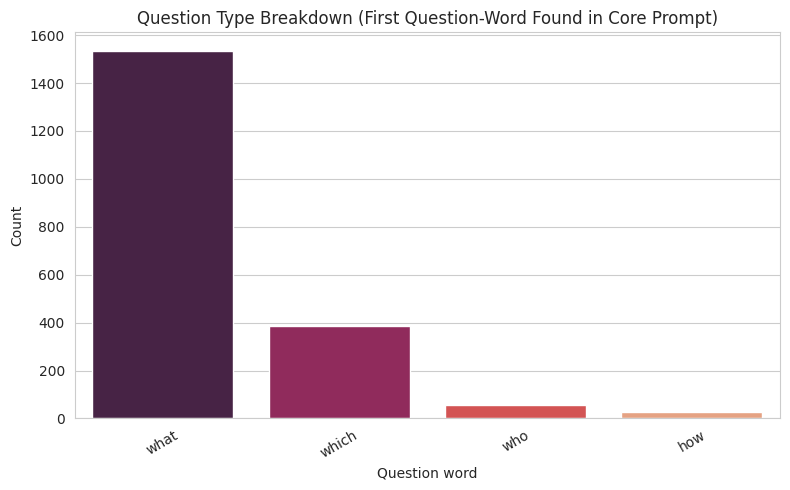


'Pick the longest option' heuristic would score: 0.349 accuracy (baseline random = 0.20)


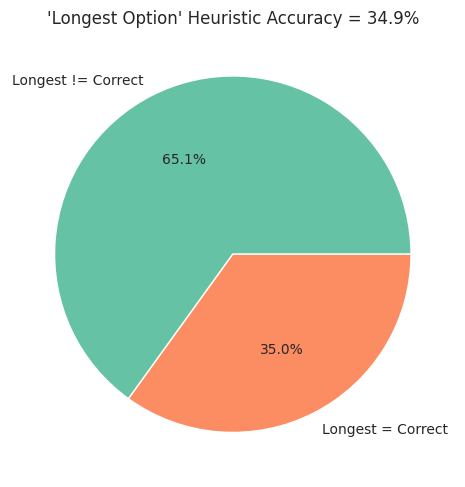

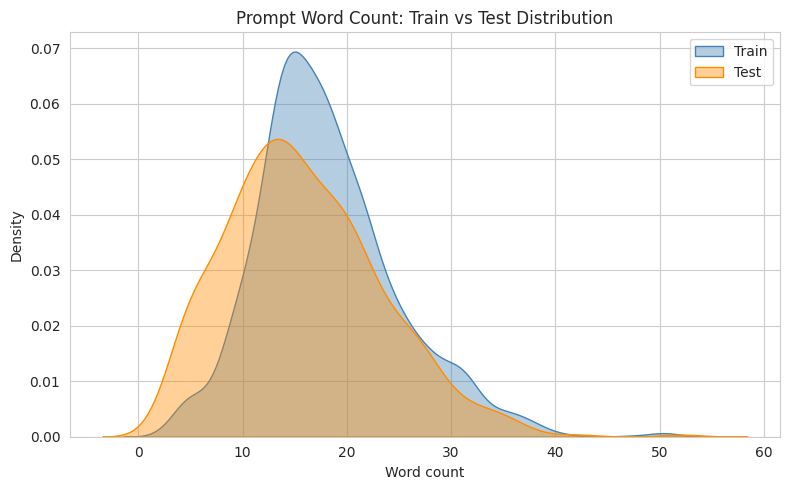

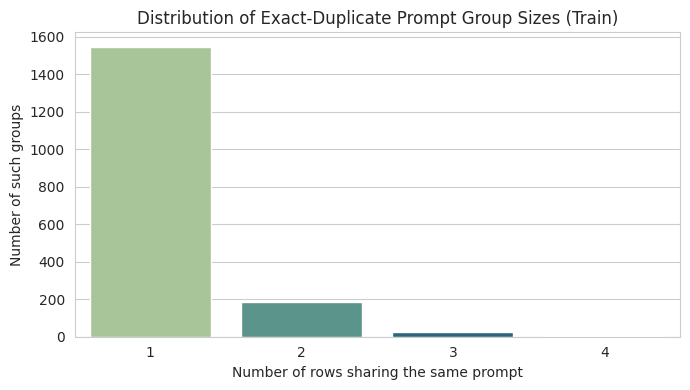

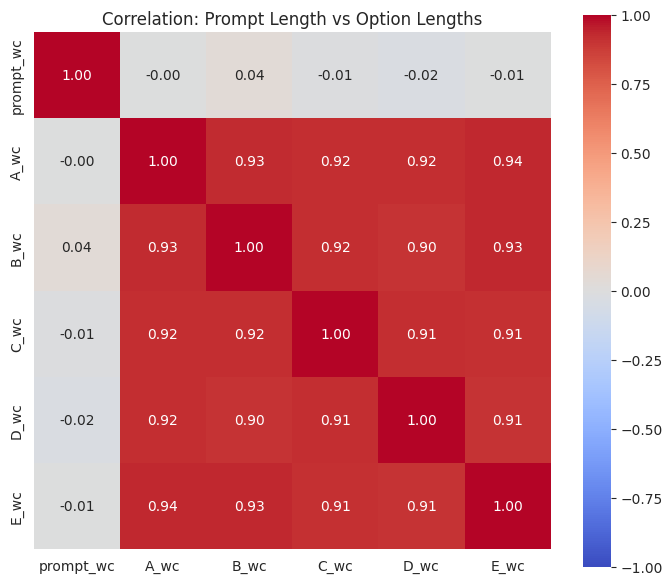


All extensive EDA plots saved to /kaggle/working/eda_outputs
Files: ['answer_distribution.png', 'duplicate_group_sizes.png', 'instruction_template_freq.png', 'length_correlation_heatmap.png', 'length_vs_correctness.png', 'longest_option_heuristic.png', 'option_length_by_slot.png', 'option_length_dist.png', 'prompt_length_dist.png', 'question_type_breakdown.png', 'top_bigrams_prompts.png', 'top_unigrams_prompts.png', 'train_vs_test_prompt_length.png', 'wordcloud_correct_answers.png', 'wordcloud_prompts.png']


In [17]:
"""
Smart MCQ Solver Challenge
Step 1b: Extensive / Detailed EDA (additional plots)

Run AFTER 01_preprocessing_eda.py (uses train_processed.csv / test_processed.csv).
Paste each '# ---- CELL ----' block into its own Kaggle notebook cell.
"""

# ---- CELL: Imports ----
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")

# ---- CELL: Paths ----
IS_KAGGLE = os.path.exists("/kaggle/input")
OUT_DIR = "/kaggle/working" if IS_KAGGLE else "."
DATA_DIR = os.path.join(OUT_DIR, "data")
EDA_DIR = os.path.join(OUT_DIR, "eda_outputs")
os.makedirs(EDA_DIR, exist_ok=True)

# ---- CELL: Load processed data (from step 1) ----
train = pd.read_csv(os.path.join(DATA_DIR, "train_processed.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test_processed.csv"))
OPTION_COLS = ["A", "B", "C", "D", "E"]

print("Train:", train.shape, "| Test:", test.shape)


# PLOT : Top 20 unigrams in prompts (bar chart)
# ================================================================
def get_top_ngrams(text_series, n=1, top_k=20):
    words = []
    for t in text_series.dropna():
        toks = str(t).split()
        toks = [w for w in toks if w not in STOPWORDS and len(w) > 2]
        if n == 1:
            words.extend(toks)
        else:
            words.extend([" ".join(toks[i:i+n]) for i in range(len(toks)-n+1)])
    return Counter(words).most_common(top_k)

top_unigrams = get_top_ngrams(train["prompt_clean"], n=1, top_k=20)
ug_df = pd.DataFrame(top_unigrams, columns=["word", "count"])

plt.figure(figsize=(8, 7))
sns.barplot(data=ug_df, x="count", y="word", hue="word", palette="crest", legend=False)
plt.title("Top 20 Unigrams in Prompts (Train, stopwords removed)")
plt.xlabel("Frequency")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "top_unigrams_prompts.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
# PLOT 8: Top 15 bigrams in prompts
# ================================================================
top_bigrams = get_top_ngrams(train["prompt_clean"], n=2, top_k=15)
bg_df = pd.DataFrame(top_bigrams, columns=["bigram", "count"])

plt.figure(figsize=(8, 6))
sns.barplot(data=bg_df, x="count", y="bigram", hue="bigram", palette="flare", legend=False)
plt.title("Top 15 Bigrams in Prompts (Train)")
plt.xlabel("Frequency")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "top_bigrams_prompts.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
# PLOT 9: Instruction-template ("wrapper") frequency
# Many prompts start with a fixed instruction phrase - let's count them.
# ================================================================
TEMPLATE_PATTERNS = {
    "Pick the best possible answer": r"^pick the best possible answer",
    "Select the most accurate option": r"^select the most accurate option",
    "Determine the correct option": r"^determine the correct option",
    "Choose the correct answer": r"^choose the correct answer",
    "Identify the correct statement": r"^identify the correct statement",
    "No fixed template / other": None,
}

def classify_template(prompt):
    p = str(prompt).strip().lower()
    for name, pat in TEMPLATE_PATTERNS.items():
        if pat and re.match(pat, p):
            return name
    return "No fixed template / other"

train["template"] = train["prompt"].apply(classify_template)
test["template"] = test["prompt"].apply(classify_template)

plt.figure(figsize=(9, 5))
template_order = train["template"].value_counts().index
sns.countplot(y="template", hue="template", data=train, order=template_order,
              palette="mako", legend=False)
plt.title("Instruction Template Frequency in Prompts (Train)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "instruction_template_freq.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
# PLOT 10: Question-type breakdown (What/Who/How/Which/etc.)
# ================================================================
QUESTION_WORDS = ["what", "who", "how", "which", "why", "when", "where", "does", "is", "are"]

def get_question_word(core_prompt):
    toks = str(core_prompt).lower().split()
    for w in toks:
        if w in QUESTION_WORDS:
            return w
    return "other"

train["q_word"] = train["core_prompt"].apply(get_question_word)

plt.figure(figsize=(8, 5))
qword_order = train["q_word"].value_counts().index
sns.countplot(x="q_word", hue="q_word", data=train, order=qword_order,
              palette="rocket", legend=False)
plt.title("Question Type Breakdown (First Question-Word Found in Core Prompt)")
plt.xlabel("Question word")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "question_type_breakdown.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
#  "Longest option wins" heuristic check
# For each row, is the correct answer the single longest option?
# ================================================================
def is_longest_correct(row):
    lengths = {c: row[f"{c}_wc"] for c in OPTION_COLS}
    longest_opt = max(lengths, key=lengths.get)
    return longest_opt == row["answer"]

train["longest_is_correct"] = train.apply(is_longest_correct, axis=1)
longest_acc = train["longest_is_correct"].mean()
print(f"\n'Pick the longest option' heuristic would score: {longest_acc:.3f} accuracy "
      f"(baseline random = 0.20)")

plt.figure(figsize=(5, 5))
train["longest_is_correct"].value_counts().rename({True: "Longest = Correct", False: "Longest != Correct"}).plot(
    kind="pie", autopct="%1.1f%%", colors=["#66c2a5", "#fc8d62"], ylabel="")
plt.title(f"'Longest Option' Heuristic Accuracy = {longest_acc:.1%}")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "longest_option_heuristic.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
# PLOT 13: Train vs Test prompt-length distribution overlay
# (sanity check that train/test come from the same distribution)
# ================================================================
plt.figure(figsize=(8, 5))
sns.kdeplot(train["prompt_wc"], label="Train", fill=True, alpha=0.4, color="steelblue")
sns.kdeplot(test["prompt_wc"], label="Test", fill=True, alpha=0.4, color="darkorange")
plt.title("Prompt Word Count: Train vs Test Distribution")
plt.xlabel("Word count")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "train_vs_test_prompt_length.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
# PLOT 14: Duplicate-group size distribution
# ================================================================
group_sizes = train["prompt"].value_counts()
plt.figure(figsize=(7, 4))
sns.countplot(x=group_sizes.values, hue=group_sizes.values, palette="crest", legend=False)
plt.title("Distribution of Exact-Duplicate Prompt Group Sizes (Train)")
plt.xlabel("Number of rows sharing the same prompt")
plt.ylabel("Number of such groups")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "duplicate_group_sizes.png"), dpi=150)
plt.show()
plt.close()

# ================================================================
# PLOT 15: Correlation heatmap of option word-count columns
# (do longer prompts correlate with longer options overall?)
# ================================================================
corr_cols = ["prompt_wc"] + wc_cols
corr = train[corr_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation: Prompt Length vs Option Lengths")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "length_correlation_heatmap.png"), dpi=150)
plt.show()
plt.close()

print(f"\nAll extensive EDA plots saved to {EDA_DIR}")
print("Files:", sorted(os.listdir(EDA_DIR)))